Core RAG Pipeline

In [1]:
import re
f= open('Leadership and Management importance in Organisations.txt','r',encoding = 'utf-8')
text = f.read()
print(f"Document loaded. Total words: {len(text.split())}")


Document loaded. Total words: 4026


Chunking

In [2]:
def chunk_text(text: str, chunk_size: int = 200, overlap: int = 40) -> list:
    words = text.split()
    chunks = []
    start = 0

    while start<len(words):
        end = start + chunk_size
        chunk = words[start:end]
        chunks.append(' '.join(chunk))
        start += chunk_size - overlap

    return chunks 

chunks = chunk_text(text)
print(f"Total number of chunks: {len(chunks)}")


Total number of chunks: 26


Embedding and Vector Store

In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

#Embedding Chunks 
chunk_embeddings = model.encode(chunks)
print(f"Embeddings shape: {chunk_embeddings.shape}")

#Implementing Cosine Similarity
def cosine_similarity(a,b):
 dot_prod = np.dot(a,b)
 norm_a = np.linalg.norm(a)
 norm_b = np.linalg.norm(b)
 return dot_prod/(norm_a*norm_b)

 #Retrieval Function
def retrieve(query: str, top_k: int = 3) -> list[str]:
 query_embedding = model.encode(query)

 scores = []
 for i,chunk_embed in enumerate(chunk_embeddings):
  score=cosine_similarity(query_embedding, chunk_embed)
  scores.append([score,i])

 scores.sort(reverse=True)

 results = []
 for score, id in scores[:top_k]:
  results.append([chunks[id],score])
 return results


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embeddings shape: (26, 384)


In [4]:
# Test queries
queries = [
    "What is emotional intelligence in leadership?",
    "Can managers be trained to become leaders?",
    "What is the role of feedback in leadership training?"
]

for query in queries:
    print(f"\nQuery: {query}")
    print("-" * 60)
    results = retrieve(query, top_k=3)
    for i, (chunk, score) in enumerate(results):
        print(f"Rank {i+1} | Score: {score:.4f}")
        print(f"{chunk[:200]}...")
        print()


Query: What is emotional intelligence in leadership?
------------------------------------------------------------
Rank 1 | Score: 0.8149
the knowledge of leaders to their performance. According to this research, leadership capabilities can be nurtured through training and experience. It follows that leadership is not set aside for the ...

Rank 2 | Score: 0.7486
intelligence is the intuitive ability to acknowledge, understand, and control individual emotions and those of other people. It determines the efficacy of a leader when it comes to the business map. H...

Rank 3 | Score: 0.7387
a significant role in determining organisational profitability. Managers can increase each element of emotional intelligence through management training. Along these lines, they develop into effective...


Query: Can managers be trained to become leaders?
------------------------------------------------------------
Rank 1 | Score: 0.7231
leader is charged with initiating actions, creating motivation, pr

Generation

In [5]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
model_t5 = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")

def rag_answer(query: str) -> str:
    results = retrieve(query, top_k=3)
    context = "\n\n".join(chunk for chunk, _ in results)
    prompt = f"""Answer the question using ONLY the context below.
If the answer is not in the context, say 'I don't know'.

Context:
{context}

Question: {query}

Answer:"""
    
    inputs = tokenizer(prompt, return_tensors="pt", 
                      max_length=512, truncation=True)
    outputs = model_t5.generate(**inputs, max_new_tokens=100)
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

# Testing queries
queries = [
    "What are the five elements of emotional intelligence?",
    "What is the capital of France?"
]

for query in queries:
    print(f"Query: {query}")
    print(f"Answer: {rag_answer(query)}")
    print("-" * 60)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Query: What are the five elements of emotional intelligence?
Answer: efficacy of a leader when it comes to the business map
------------------------------------------------------------
Query: What is the capital of France?
Answer: I don't know
------------------------------------------------------------


Hallucination Stress Test

Query: What are the five elements of emotional intelligence?
Type: answerable
Top chunk (first 100 words): intelligence is the intuitive ability to acknowledge, understand, and control individual emotions and those of other people. It determines the efficacy of a leader when it comes to the business map. However, in spite of vast research on emotional intelligence, many managers disdain this topic. Daniel Goleman, an American psychologist, advances that a high degree of IQ and technical skills are undoubtedly among the most important predetermining factors in the selection of leaders. However, Goleman (2012) proceeds to reveal that the most effective leaders possess of exceptional emotional intelligence. This factor has a significant impact on the successfulness of organisations.
Cosine score: 0.6394
Answer: efficacy of a leader when it comes to the business map
------------------------------------------------------------
Query: Can managers be trained to be leaders?
Type: answerable
T

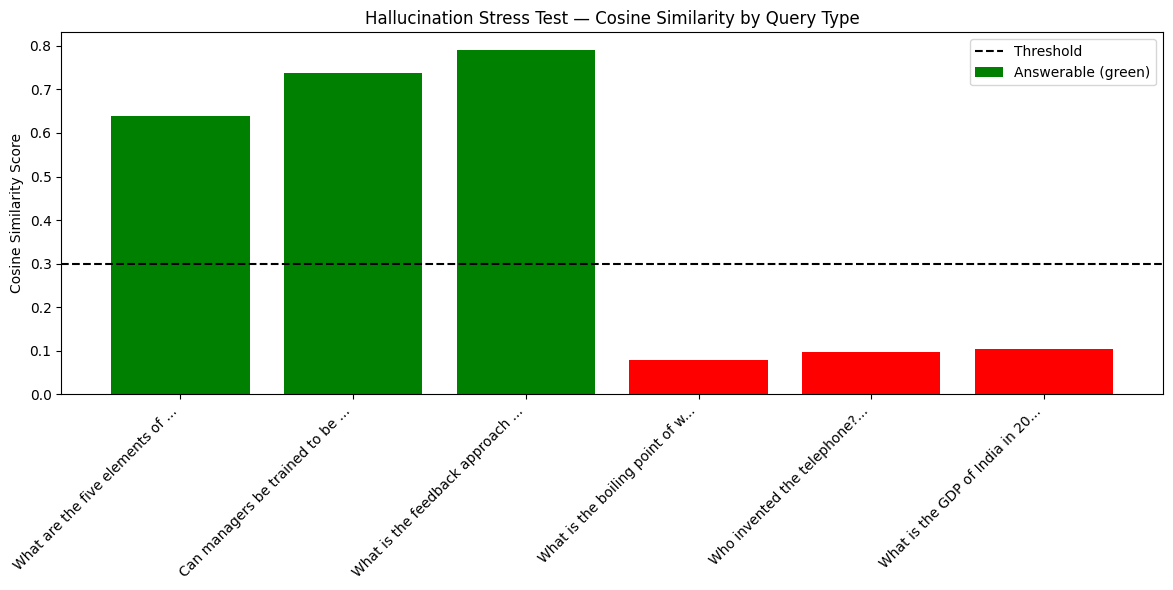

In [6]:
import matplotlib.pyplot as plt

# 6 queries - 3 answerable, 3 out of scope
queries_stress = [
    ("What are the five elements of emotional intelligence?", "answerable"),
    ("Can managers be trained to be leaders?", "answerable"),
    ("What is the feedback approach in leadership training?", "answerable"),
    ("What is the boiling point of water?", "out-of-scope"),
    ("Who invented the telephone?", "out-of-scope"),
    ("What is the GDP of India in 2024?", "out-of-scope")
]

results_log = []

for query, qtype in queries_stress:
    # Retrieve
    results = retrieve(query, top_k=3)
    top_chunk, top_score = results[0]
    
    answer = rag_answer(query)
    
    # Log
    results_log.append({
        'query': query,
        'type': qtype,
        'top_chunk': top_chunk,
        'score': top_score,
        'answer': answer
    })
    
    print(f"Query: {query}")
    print(f"Type: {qtype}")
    print(f"Top chunk (first 100 words): {' '.join(top_chunk.split()[:100])}")
    print(f"Cosine score: {top_score:.4f}")
    print(f"Answer: {answer}")
    print("-" * 60)

# Plot
colors = ['green' if r['type'] == 'answerable' else 'red' for r in results_log]
scores = [r['score'] for r in results_log]
labels = [r['query'][:30] + '...' for r in results_log]

plt.figure(figsize=(12, 6))
bars = plt.bar(labels, scores, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cosine Similarity Score')
plt.title('Hallucination Stress Test — Cosine Similarity by Query Type')
plt.axhline(y=0.3, color='black', linestyle='--', label='Threshold (0.3)')
plt.legend(['Threshold', 'Answerable (green)', 'Out-of-scope (red)'])
plt.tight_layout()
plt.show()